# Lecture 21 - (Part 1) Multi-class SVM, Slack Variables & Soft-Margin SVM. (Part 2) Performance Measures for Classification Tasks

---

# Kernel Function

An inner product is a function that takes two inputs from a space and outputs a single value by combining the inputs, and is expressed as $\langle\mathbf{x},\mathbf{y}\rangle$. For example, the dot product between two vectors: $\langle\mathbf{x},\mathbf{y}\rangle = \mathbf{x}\cdot\mathbf{y} = \sum_{i=1}^d x_iy_i$. 

A **kernel** is a function that calculates the inner product in an enlarged feature space using only values from the original feature space, and is expressed as $K(\mathbf{x},\mathbf{y})$. For example, using the mapping $\phi(\mathbf{x})$ below,

\begin{align*}
\phi: \mathbb{R}^2 &\longrightarrow \mathbb{R}^3 \\
[x_1,x_2] &\longmapsto [x_1^2, \sqrt{2}x_1x_2, x_2^2]
\end{align*}

the related kernel for the dot product in the enlarged space is

\begin{align*}
K((x_1,x_2),(y_1,y_2)) &= \langle(x_1^2,\sqrt{2}x_1x_2,x_2^2),(y_1^2,\sqrt{2}y_1y_2,y_2^2)\rangle\\
&= x_1^2x_2^2 + 2x_1x_2y_1y_2 + y_1^2y_2^2\\
&= (x_1x_2 + y_1y_2)^2
\end{align*}

* The inner product of two instances is calculated in the feature space.
* A mapping sends these instances to the enlarged space. $[x_1,x_2]$ maps to $[x_1^2, \sqrt{2}x_1x_2, x_2^2]$ and $[y_1,y_2]$ maps to $[y_1^2, \sqrt{2}y_1y_2, y_2^2]$.
* The inner product between the instances is calculated in the enlarged space.
* The kernel, $K(\mathbf{x},\mathbf{y})$, encodes this mapping and then the inner product. Sometimes the kernel is calculated directly from the feature space.

Kernels used in support vector classification typically measure the similarity or distance between instances. The most commonly used kernels for support vector classifiers are listed below.

### Common Kernels

1. **Polynomial kernel**

$$K(\mathbf{x},\mathbf{y}) = (1 + \langle\mathbf{x},\mathbf{y}\rangle)^d$$

Instances are mapped into an enlarged space of polynomial powers similar to the example at the section's start. The decision boundary will curve some.

2. **Radial Basis Function (RBF) kernel**

$$K(\mathbf{x},\mathbf{y}) = e^{-\gamma \Vert\mathbf{x}-\mathbf{y}\Vert^2}$$

Instances are mapped into an enlarged space where each dimension is related to the distance from one instance. An instance that is closer to a dimension's instance in the feature space will have a larger value. The decision boundary will curve around clusters of instances of the same class.

3. **Sigmoid kernel**

$$K(\mathbf{x},\mathbf{y}) = \text{tanh}(\gamma\langle\mathbf{x},\mathbf{y}\rangle + 1)$$

The sigmoid function is used due to a similar response to biological neurons. The sigmoid function restricts the gains from large inputs to between -1 and 1, reducing the spread of values in the enlarged space.

## The Kernel Trick

The kernel trick uses a kernel in place of the inner product. A support vector machine (SVM) is a support vector classifier that utilizes the kernel trick.

---

In order to classify new data points using the trained model, we evaluate the sign of $y(x) = w^T\phi(x) + b$. This can be expressed in terms of the parameters $\{a_n\}$ and the kernel function by substituting for $w$ to give

$$y(x) = \sum_{n=1}^N a_n t_n K(x,x_n) + b$$

* A constrained optimization of this form satisfies the Karush-Kuhn-Tucker (KKT) conditions, which in this case require that the following three properties hold

\begin{align*}
& a_n \geq 0 \\
& t_n y(x_n) - 1 \geq 0 \\
& a_n \left(t_n y(x_n) - 1\right) = 0
\end{align*}

Thus for every data point, either $a_n = 0$ or $t_n y(x_n) = 1$. 
* Any data point for which $a_n = 0$ will not appear in the sum of $y(x)$ and hence plays no role in making predictions for new data points. 

* The remaining data points are called **support vectors**, and because they satisfy $t_n y(x_n) = 1$, they correspond to points that lie on the maximum margin hyperplanes in feature space. 

* Once the model is trained, a significant proportion of the data points can be discarded and only the support vectors retained!

Having solved the quadratic programming problem and found a value for $a$, we can then determine the value of the threshold parameter $b$ by noting that any support vector $x_n$ satisfies $t_n y(x_n) = 1$.

$$t_n \left(\sum_{m\in S}a_m t_m K(x_n,x_m) + b\right) = 1$$

where $S$ denotes the set of indices of the support vectors. Although we can solve this equation for $b$ using an arbitrarily chosen support vector $x_n$, a numerically more stable solution is obtained by first multiplying through by $t_n$, making use of $t_n^2 = 1$, and then averaging these equations over all support vectors and solving for $b$ to give

$$b = \frac{1}{N_S} \sum_{n\in S}\left(t_n - \sum_{m\in S}a_m t_m K(x_n, x_m)\right)$$

where $N_S$ is the total number of support vectors.

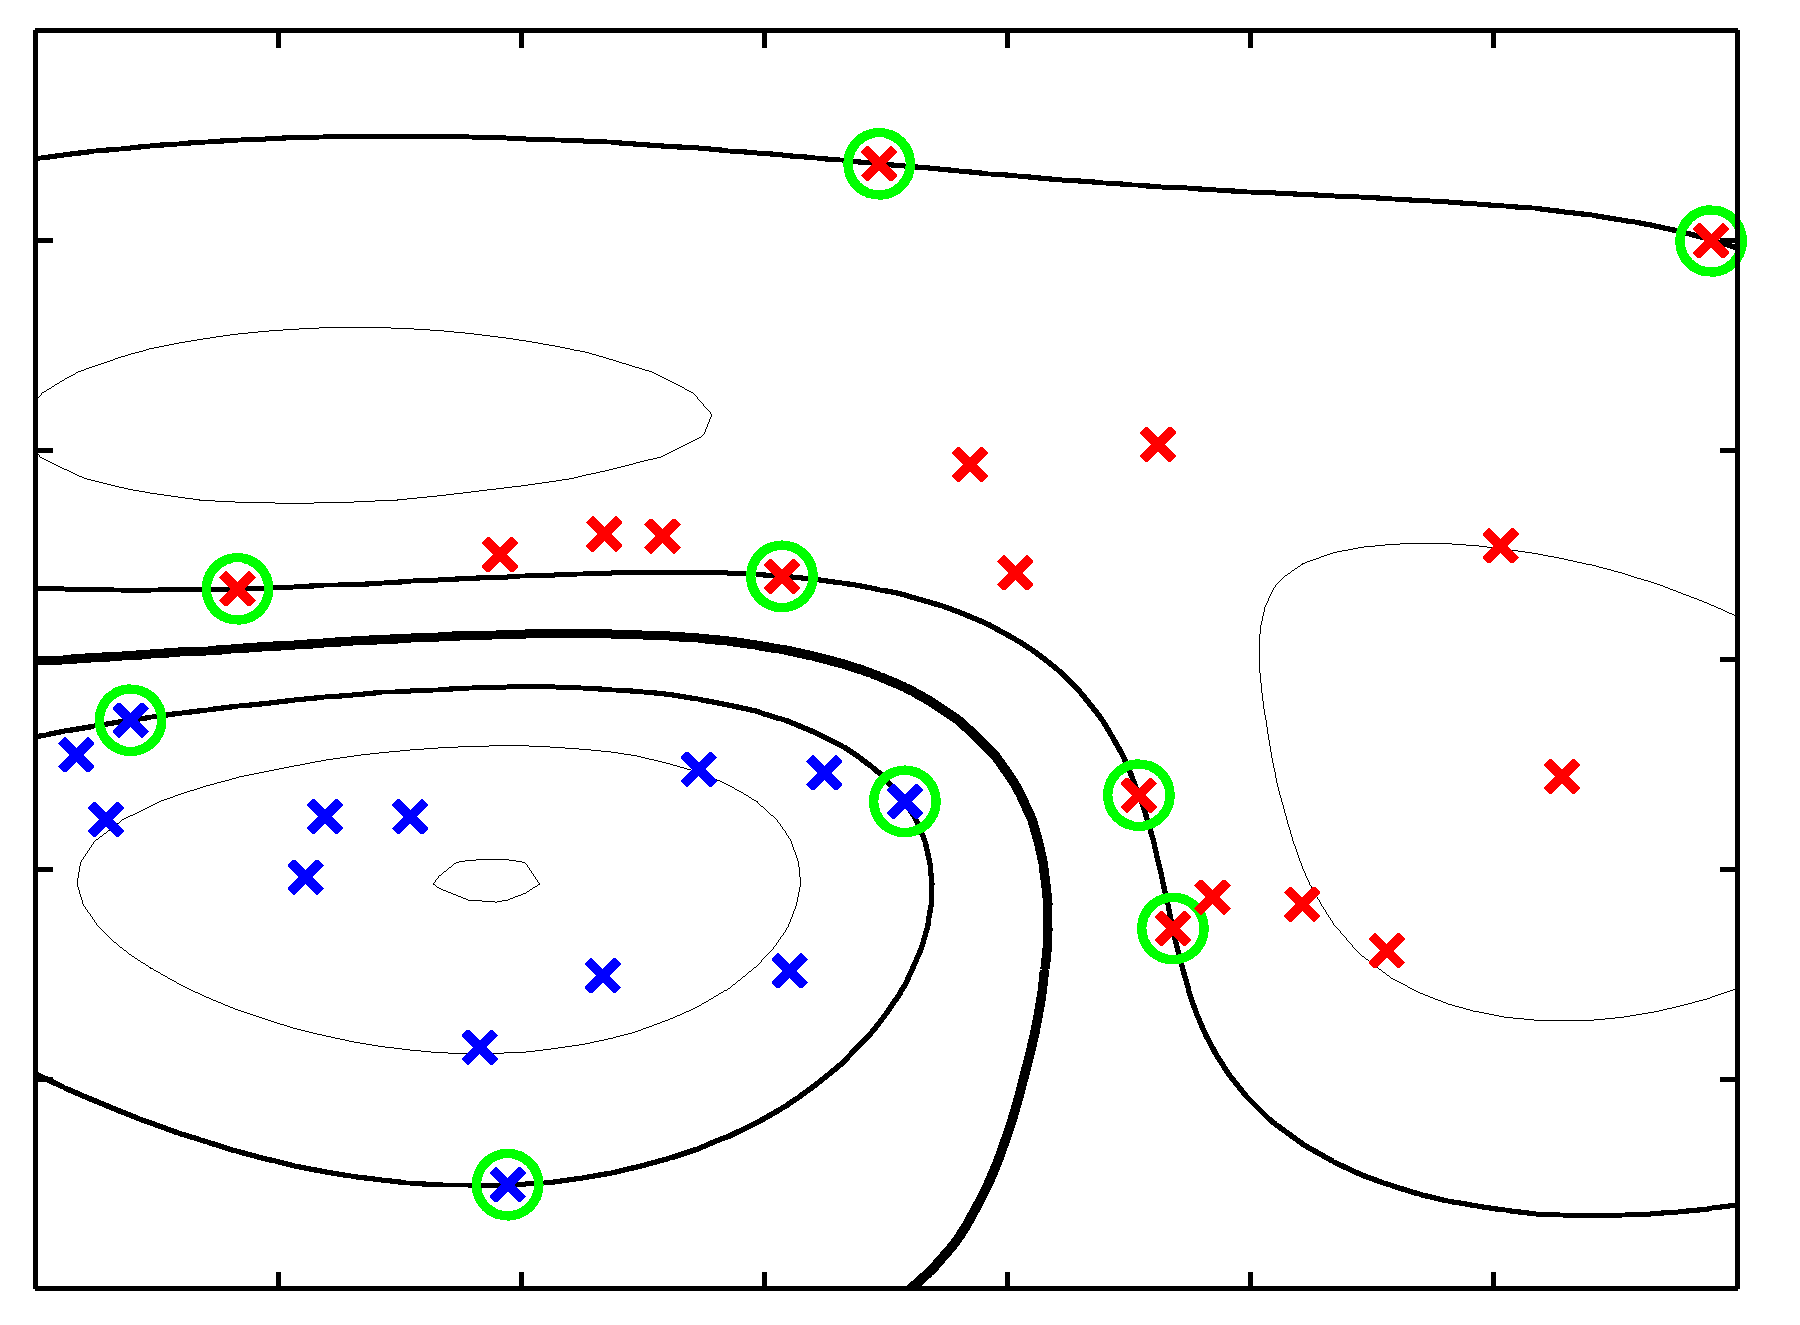

In [1]:
from IPython.display import Image
Image("figures/Figure7.2.png", width=400)
#Source: Bishop textbook

Although the data set is not linearly separable in the two-dimensional data space $x$, it is linearly separable in the nonlinear feature space defined implicitly by the nonlinear kernel function. Thus the training data points are perfectly separated in the original data space.

This example also provides a geometrical insight into the origin of sparsity in the SVM. The maximum margin hyperplane is defined by the location of the support vectors. Other data points can be moved around freely (so long as they remain outside the margin region) without changing the decision boundary, and so the solution will be independent of such data points.

---

## Code Example of Hard-Margin SVM

Linearly-separable classes in the feature space spanned by the transformation $\phi(x)$ may form a non-linear decision boundary in the input space.

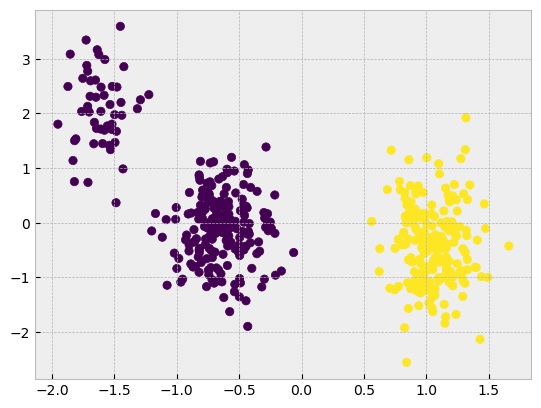

In [4]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')
from sklearn.preprocessing import StandardScaler

X = np.load('data.npy')
t = np.load('labels.npy')

scaler = StandardScaler()
X=scaler.fit_transform(X)
plt.scatter(X[:, 0], X[:, 1], c=t);

In [7]:
from sklearn.svm import SVC # "Support vector classifier"

# SVC?

In [8]:
svm = SVC(kernel='linear', C=1E6)
svm.fit(X, t)

SVC(C=1000000.0, kernel='linear')

In [9]:
#source: https://jakevdp.github.io/PythonDataScienceHandbook/05.07-support-vector-machines.html

def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, edgecolors='black',facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

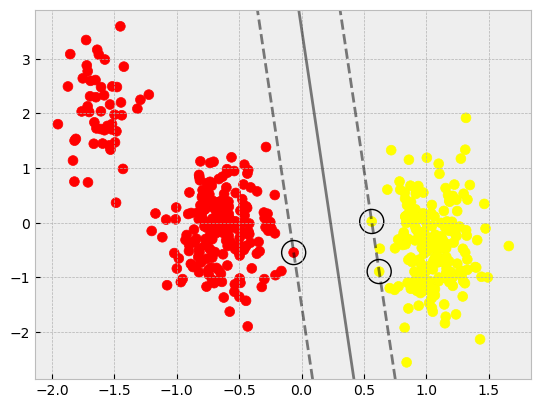

In [10]:
plt.scatter(X[:, 0], X[:, 1], c=t, s=50, cmap='autumn')
plot_svc_decision_function(svm);

In [11]:
svm.support_vectors_

array([[-0.06343854, -0.5479684 ],
       [ 0.56176003,  0.02103463],
       [ 0.62170369, -0.89592457]])

---

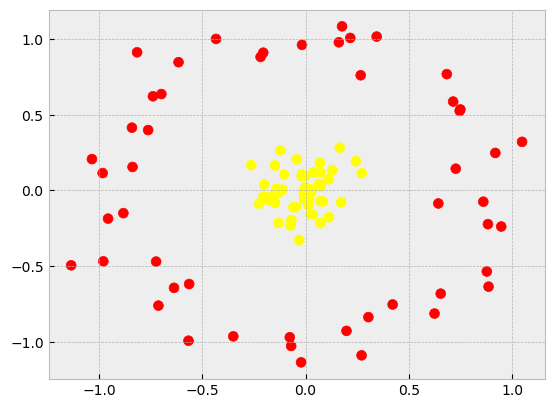

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

X, t = make_circles(100, factor=.1, noise=.1)
plt.scatter(X[:,0], X[:,1], c=t, s=50, cmap='autumn');

X_train, X_test, t_train, t_test = train_test_split(X, t,
                                                   test_size=0.3,
                                                   stratify=t,
                                                   random_state=0)

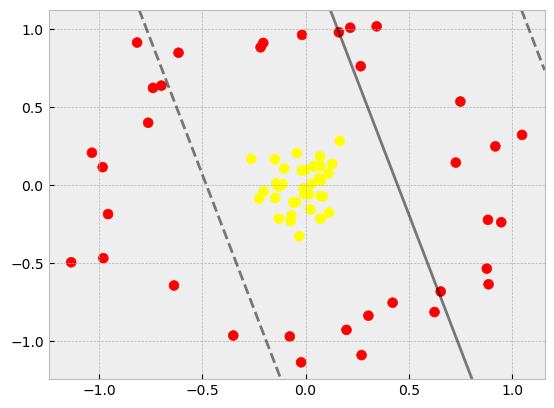

In [13]:
clf = SVC(kernel='linear')
clf.fit(X_train, t_train)

plt.scatter(X_train[:, 0], X_train[:, 1], c=t_train, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

In [14]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X_train, t_train)

SVC(C=1000000.0)

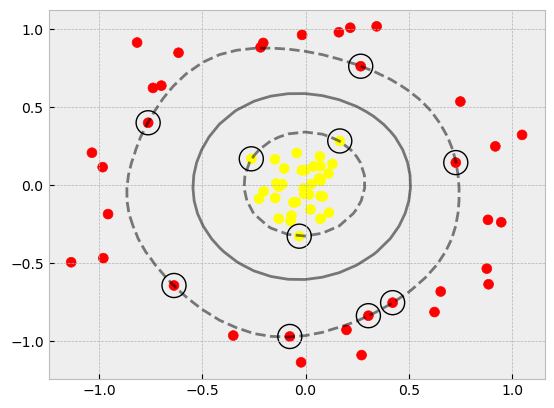

In [15]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=t_train, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none');

In [16]:
clf.decision_function(X_test)

array([ 0.99786018, -0.997964  , -1.24574841,  1.60967376,  1.54462745,
       -0.82734634,  1.31864512, -0.6261371 ,  1.01802728,  1.61801708,
       -1.57596375, -1.08625863, -0.94925067, -1.15178056,  1.14705446,
        1.61973642, -1.21986785, -1.20229971, -1.3229196 , -1.55691235,
        1.3503579 ,  1.40891826, -1.40729769,  1.33923991,  1.42207488,
        1.56433947,  1.49642076, -1.42103818, -1.04672606,  1.43529331])

In [17]:
1*(clf.decision_function(X_test)>0)

array([1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1])

In [18]:
y_test = clf.predict(X_test)
y_test

array([1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 1])

In [19]:
clf.score(X_test, t_test)
# accuracy

1.0

In [20]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(t_test, y_test))

[[15  0]
 [ 0 15]]


---

# Multi-Class SVM

SVM uses a one-vs-all approach and picks the class for which the confidence (distance) is largest from its hyperplane.

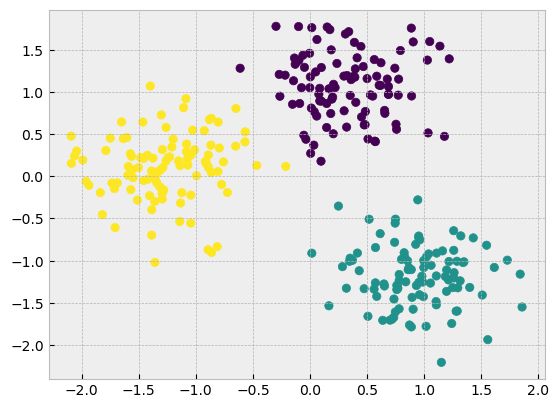

In [21]:
from sklearn.datasets import make_blobs

X, t = make_blobs(n_samples=300, centers=3,
                  random_state=0, cluster_std=0.60)
scaler = StandardScaler()
X = scaler.fit_transform(X)
plt.scatter(X[:, 0], X[:, 1], c=t);

In [22]:
np.unique(t, return_counts=True)

(array([0, 1, 2]), array([100, 100, 100]))

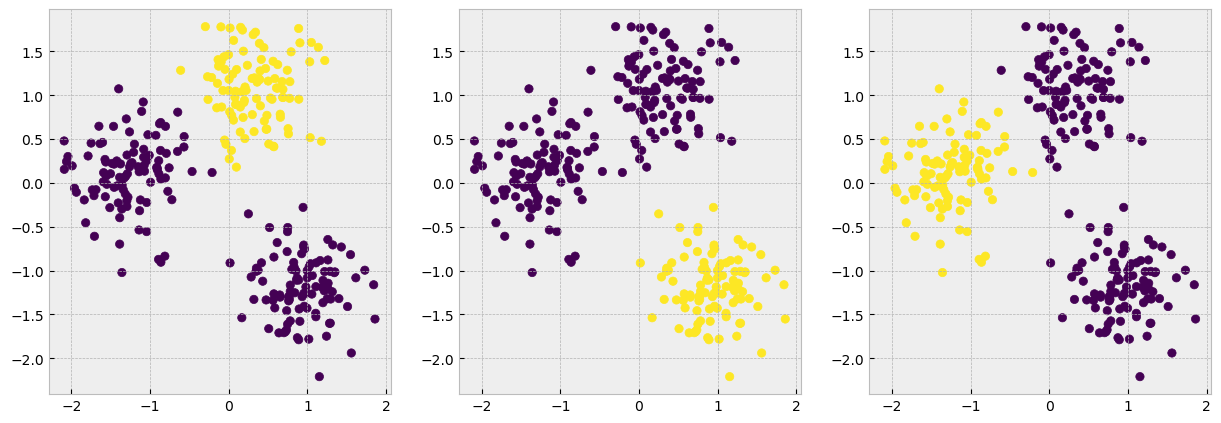

In [23]:
t0 = 1*(t==0)
t1 = 1*(t==1)
t2 = 1*(t==2)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.scatter(X[:, 0], X[:, 1], c=t0)
plt.subplot(1,3,2); plt.scatter(X[:, 0], X[:, 1], c=t1)
plt.subplot(1,3,3); plt.scatter(X[:, 0], X[:, 1], c=t2);

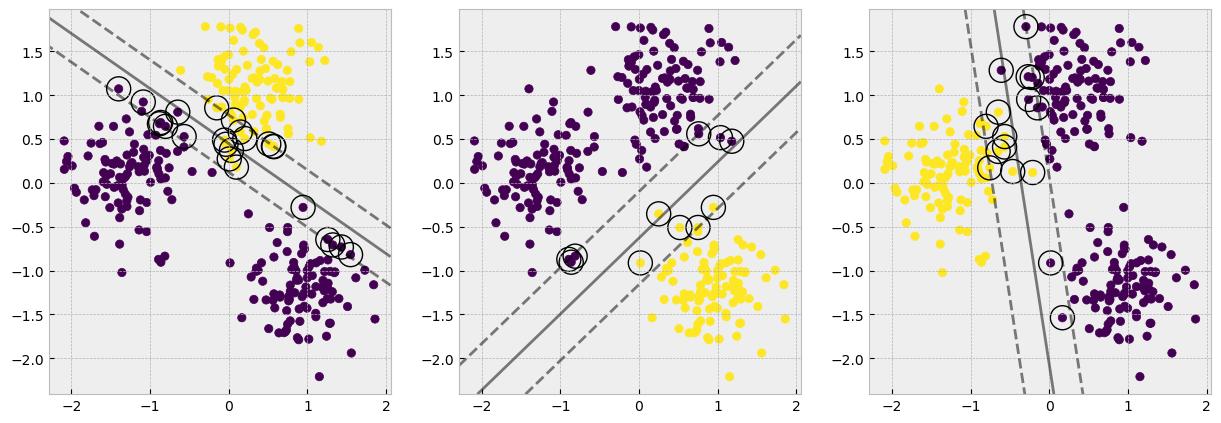

In [24]:
plt.figure(figsize=(15,5))

# Soft-margin SVM

plt.subplot(1,3,1); plt.scatter(X[:, 0], X[:, 1], c=t0)
svm0 = SVC(kernel='linear', random_state=0)
svm0.fit(X, t0)
plot_svc_decision_function(svm0)

plt.subplot(1,3,2); plt.scatter(X[:, 0], X[:, 1], c=t1)
svm1 = SVC(kernel='linear', random_state=0)
svm1.fit(X, t1)
plot_svc_decision_function(svm1)

plt.subplot(1,3,3); plt.scatter(X[:, 0], X[:, 1], c=t2)
svm2 = SVC(kernel='linear', random_state=0)
svm2.fit(X, t2)
plot_svc_decision_function(svm2);

In [25]:
x = [[0,0]]
# x = [[0,-1]]

In [26]:
svm0.decision_function(x)

array([-1.37371395])

In [27]:
svm1.decision_function(x)

array([-1.18661832])

In [28]:
svm2.decision_function(x)

array([-0.97132968])

This point will be labeled as class 2.

In [29]:
t

array([0, 1, 0, 2, 2, 2, 1, 0, 2, 2, 1, 1, 1, 0, 1, 2, 0, 0, 2, 1, 2, 0,
       1, 0, 2, 2, 0, 2, 1, 1, 2, 0, 0, 1, 1, 2, 1, 2, 0, 1, 2, 1, 0, 1,
       1, 2, 1, 2, 2, 1, 2, 1, 2, 2, 1, 0, 0, 2, 2, 0, 1, 1, 0, 2, 1, 2,
       0, 1, 0, 1, 2, 2, 2, 2, 1, 0, 1, 2, 0, 0, 2, 0, 1, 0, 0, 0, 1, 2,
       0, 0, 2, 1, 2, 0, 1, 1, 0, 1, 2, 0, 1, 2, 0, 1, 0, 0, 2, 0, 1, 1,
       0, 2, 0, 0, 2, 2, 0, 0, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 2, 2,
       0, 2, 2, 1, 2, 0, 2, 2, 1, 0, 1, 0, 2, 2, 0, 2, 2, 1, 0, 2, 0, 1,
       2, 2, 1, 1, 0, 1, 0, 0, 1, 0, 2, 0, 0, 0, 0, 2, 1, 0, 2, 1, 1, 1,
       0, 1, 0, 0, 1, 2, 0, 0, 0, 0, 1, 2, 0, 2, 0, 0, 1, 1, 2, 0, 1, 2,
       0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 1, 0, 0, 2, 1, 1, 1, 1, 0, 2, 1,
       0, 1, 1, 1, 0, 2, 2, 0, 0, 2, 0, 1, 1, 0, 1, 2, 2, 2, 0, 0, 1, 2,
       2, 2, 2, 1, 2, 2, 0, 1, 1, 0, 1, 1, 2, 0, 1, 2, 0, 0, 2, 0, 2, 2,
       0, 2, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 1, 0, 0, 1, 1, 1, 2, 1,
       2, 2, 1, 1, 2, 2, 2, 1, 0, 0, 2, 1, 0, 2])

In [30]:
svm_all = SVC(kernel='linear', random_state=0)
svm_all.fit(X, t)

SVC(kernel='linear', random_state=0)

In [31]:
svm_all.predict(x)

# OvO - One-vs-One

array([0])

---

# Soft-Margin Support Vector Machine (SVM): Overlapping Classes

To handle this case, the SVM implementation has a bit of a fudge-factor which "softens" the margin: that is, it allows some of the points to creep into the margin if that allows a better fit. The hardness of the margin is controlled by a tuning parameter, most often known as **slack varible** $\xi_n \geq 0$, $n=1,\dots, N$, with one slack variable for each training data point. For very large $\xi$, the margin is hard, and points cannot lie in it. For smaller $\xi$, the margin is softer, and can grow to encompass some points.

A **slack variable** is defined as $\xi_n = 0$ for data points that are on or inside the correct margin boundary and $\xi_n = |t_n - y(x_n)|$ for other points. Thus a data point that is on the decision boundary $y(x_n) = 0$ will have $\xi_n = 1$, and points with $\xi_n > 1$ will be misclassified. The exact classification constraints are then replaced with

$$t_n y(x_n) \geq 1 - \xi_n, n = 1, \dots, N$$

in which the slack variables are constrained to satisfy $\xi_n \geq 0$. 

* Data points for which $\xi_n = 0$ are correctly classified and are either on the margin or on the correct side of the margin. 
* Points for which $0 < \xi_n \leq 1$ lie inside the margin, but on the correct side of the decision boundary.
* And those data points for which $\xi_n > 1$ lie on the wrong side of the decision boundary and are misclassified.

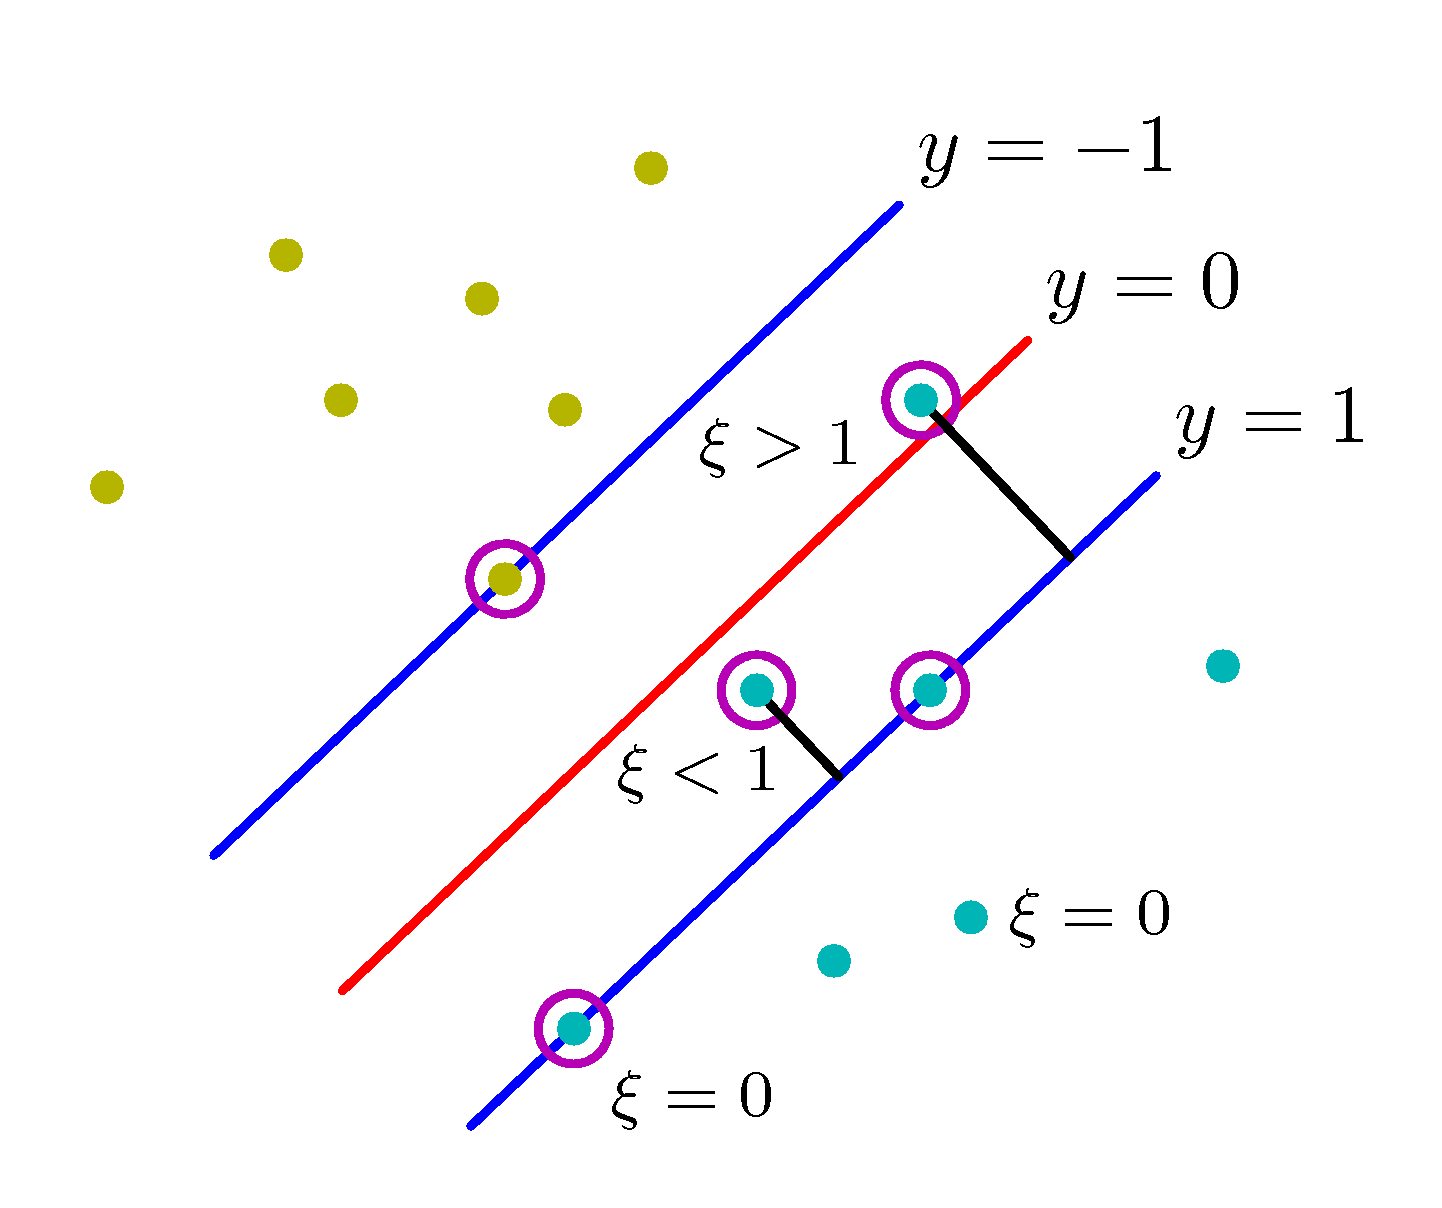

In [2]:
Image('figures/Figure7.3.png', width=400)
# Source: Bishop textbook

Our goal is now to maximize the margin while softly penalizing points that lie on the wrong side of the margin boundary. We therefore minimize:

\begin{align*}
&\arg_{w,b} \min \frac{1}{2} \Vert w\Vert^2 + C\sum_{n=1}^N \xi_n\\
\text{subject to    } &t_n y(x_n) \geq 1 - \xi_n, n = 1, \dots, N\\
\text{and    } &\xi_n \geq 0, n = 1, \dots, N
\end{align*}

where the parameter $C>0$ controls the trade-off between the slack variable penalty and the margin.

* Because any point that is misclassified has $\xi_n >1$, it follows that $\sum_n \xi_n$ is an upper bound on the number of misclassified points. 
* The parameter $C$ is therefore analogous to (the inverse of) a regularization coefficient because it controls the trade-off between minimizing training errors and controlling model complexity.
* In the limit $C \rightarrow \infty$, we will recover the earlier support vector machine for separable data.

The Lagrangian is given by:

\begin{align*}
L(w,b,a) = \frac{1}{2} \Vert w\Vert^2 + C\sum_{n=1}^N \xi_n - \sum_{n=1}^N a_n \left(t_n y(x_n) - 1 + \xi_n\right) - \sum_{n=1}^N \mu_n\xi_n
\end{align*}

where $\{a_n \geq 0\}_{n=1}^N$ and $\{\mu_n \geq 0\}_{n=1}^N$ are Lagrange multipliers. The corresponding set of 
Karush–Kuhn–Tucker (KKT) conditions are given by

\begin{align*}
a_n & \geq 0 \\
t_n y(x_n) - 1 + \xi_n & \geq 0 \\
a_n(t_n y(x_n) - 1 + \xi_n) & \geq 0 \\
\mu_n & \geq 0 \\
\xi_n & \geq 0\\
\mu_n \xi_n & = 0
\end{align*}

where $n = 1, \dots, N$.

We now optimize for $w$, $b$ and $\{\xi_n\}$:

\begin{align*}
\frac{\partial L}{\partial w} = 0 \Rightarrow & w = \sum_{n=1}^N a_n t_n \phi(x_n) \\
\frac{\partial L}{\partial b} = 0 \Rightarrow & \sum_{n=1}^N a_n t_n = 0 \\
\frac{\partial L}{\partial \xi_n} = 0 \Rightarrow & a_n = C - \mu_n \Rightarrow a_n \leq C
\end{align*}

The dual Lagrangian is then given by:

\begin{align*}
\tilde{L}(a) = \sum_{n=1}^N a_n - \frac{1}{2}\sum_{n=1}^N\sum_{m=1}^N a_n a_m t_n t_m K(x_n, x_m)
\end{align*}

which is identical to the separable case, except that the constraints are somewhat different. We therefore have to minimize $\tilde{L}(a)$ with respect to the dual variables $\{a_n\}$ subject to

\begin{align*}
0 \leq a_n \leq C
\end{align*}

\begin{align*}
\sum_{n=1}^N a_n t_n = 0
\end{align*}

As before, a subset of the data points may have $a_n = 0$, in which case they do not contribute to the predictive model. The remaining data points constitute the support vectors. These have $a_n > 0$ and hence $t_n y(x_n) = 1 - \xi_n$.

* If $a_n < C$, then $\mu_n > 0$, which requires $\xi_n = 0$ and hence such points lie on the margin. 

* Points with $a_n = C$ can lie inside the margin and can either be correctly classified if $\xi_n \leq 1$ or misclassified if $\xi_n >1$.

To determine the parameter $b$, we note that those support vectors for which $0 < a_n < C$ have $\xi_n = 0$ so that $t_n y(x_n) = 1$ and hence will satisfy

\begin{align*}
t_n \left(\sum_{m\in S} a_m t_m K(x_n, x_m) + b\right) = 1
\end{align*}

Again, a numerically stable solution is obtained by averaging to give

\begin{align*}
b = \frac{1}{N_M} \sum_{n\in M}\left(t_n - \sum_{m\in S} a_m t_m K(x_n, x_m)\right)
\end{align*}

where $M$ denotes the set of indices of data points having $0 < a_n < C$.

Although predictions for new inputs are made using only the support vectors, the training phase (i.e., the determination of the parameters $a$ and $b$) makes use of the whole data set, and so it is important to have **efficient algorithms for solving the quadratic programming problem**.

We first note that the objective function $\tilde{L}(a)$ is quadratic and so any local optimum will also be a **global
optimum** provided the constraints define a convex region (which they do as a consequence of being linear).

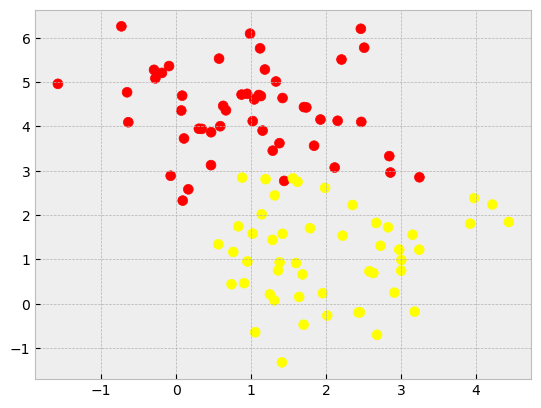

In [32]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

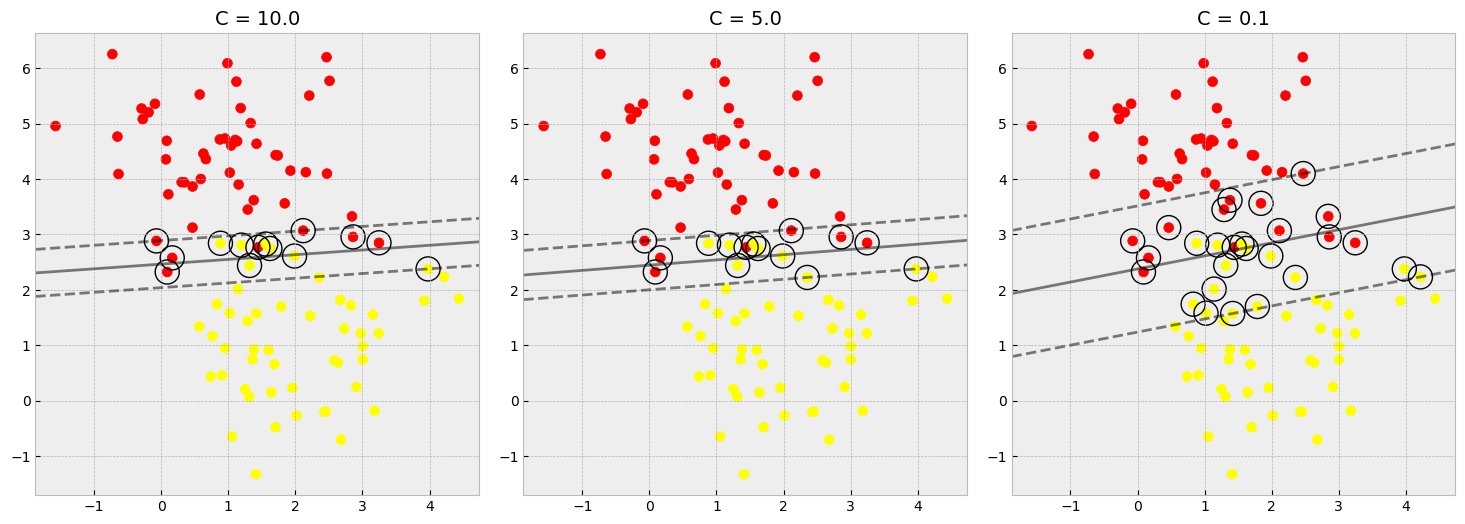

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [10, 5, 0.1]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)

The optimal value for the $C$ parameter will depend on your dataset, and should be tuned using cross-validation or a similar procedure.

---

# Example: Face Recognition

As an example of support vector machines in action, let's take a look at the facial recognition problem. We will use the Labeled Faces in the Wild dataset, which consists of several thousand collated photos of various public figures. A fetcher for the dataset is built into Scikit-Learn:

In [36]:
from sklearn.datasets import fetch_lfw_people

faces = fetch_lfw_people(min_faces_per_person=60)

print(faces.target_names)
print(faces.images.shape)

['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
(1348, 62, 47)


Let's plot a few of these faces to see what we're working with:

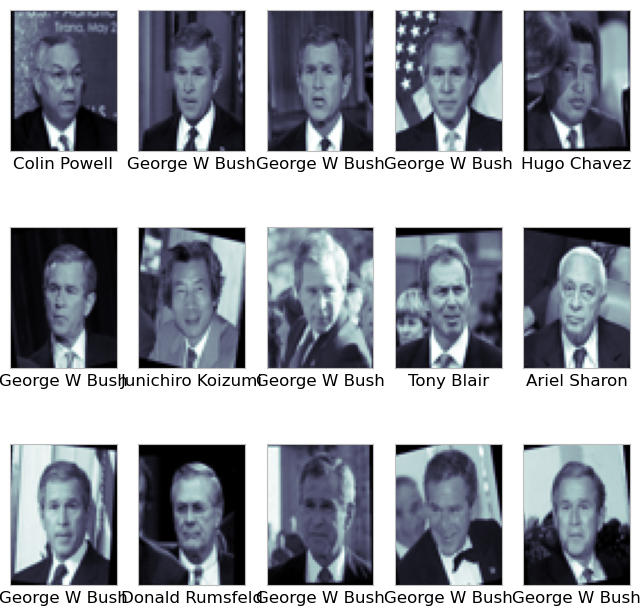

In [37]:
fig, ax = plt.subplots(3, 5, figsize=(8,8))
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])

In [38]:
X = faces.data
t = faces.target

X.shape, t.shape

((1348, 2914), (1348,))

Each image contains $62\times 47$ or 2,914 pixels. We could proceed by simply using each pixel value as a feature, but often it is more effective to use some sort of pre-processor to extract more meaningful features; here we will use a PCA to extract 150 fundamental components to feed into our support vector machine classifier. We can do this most straightforwardly by packaging the preprocessor and the classifier into a single pipeline:

In [39]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

pipe = Pipeline(steps=[('STD', MinMaxScaler()),
                      ('PCA', PCA(n_components=150)), # dimensionality reduction 
                      ('SVM', SVC(kernel='rbf', class_weight='balanced'))])

pipe

Pipeline(steps=[('STD', MinMaxScaler()), ('PCA', PCA(n_components=150)),
                ('SVM', SVC(class_weight='balanced'))])

For the sake of testing our classifier output, we will split the data into a training and testing set:

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, t_train, t_test = train_test_split(X, t, 
                                                    stratify=t,
                                                    test_size=0.2,
                                                    random_state=0)

X_train.shape, X_test.shape, t_train.shape, t_test.shape

((1078, 2914), (270, 2914), (1078,), (270,))

Finally, we can use a grid search cross-validation to explore combinations of parameters. Here we will adjust ```C``` (which controls the margin hardness) and ```gamma``` (which controls the size of the radial basis function kernel), and determine the best model:

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = dict(SVM__C=[1, 5, 10, 50],
                  SVM__gamma=[0.0001, 0.0005, 0.001, 0.005])

grid = GridSearchCV(pipe, param_grid, refit=True, verbose=2)

grid.fit(X_train, t_train)

print(grid.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END ........................SVM__C=1, SVM__gamma=0.0001; total time=   0.5s
[CV] END ........................SVM__C=1, SVM__gamma=0.0001; total time=   0.6s
[CV] END ........................SVM__C=1, SVM__gamma=0.0001; total time=   0.6s
[CV] END ........................SVM__C=1, SVM__gamma=0.0001; total time=   0.6s
[CV] END ........................SVM__C=1, SVM__gamma=0.0001; total time=   0.6s
[CV] END ........................SVM__C=1, SVM__gamma=0.0005; total time=   0.4s
[CV] END ........................SVM__C=1, SVM__gamma=0.0005; total time=   0.3s
[CV] END ........................SVM__C=1, SVM__gamma=0.0005; total time=   0.6s
[CV] END ........................SVM__C=1, SVM__gamma=0.0005; total time=   0.5s
[CV] END ........................SVM__C=1, SVM__gamma=0.0005; total time=   0.7s
[CV] END .........................SVM__C=1, SVM__gamma=0.001; total time=   0.6s
[CV] END .........................SVM__C=1, SVM_

In [44]:
final_model = grid.best_estimator_

final_model

Pipeline(steps=[('STD', MinMaxScaler()), ('PCA', PCA(n_components=150)),
                ('SVM', SVC(C=50, class_weight='balanced', gamma=0.001))])

In [45]:
from scipy import stats
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

scores = cross_val_score(final_model, X_train, t_train,
                        scoring='accuracy',
                        cv=KFold(5,shuffle=True, random_state=0))

confidence = 0.95
print('Validation 95% CI = ', stats.t.interval(confidence, len(scores)-1, loc = scores.mean(),
                                     scale=scores.std(ddof=1)/np.sqrt(len(scores))))

Validation 95% CI =  (0.7419749528113305, 0.7923144528734242)


The optimal values fall toward the middle of our grid; if they fell at the edges, we would want to expand the grid to make sure we have found the true optimum.

Now with this cross-validated model, we can predict the labels for the test data, which the model has not yet seen:

In [46]:
y_train = final_model.predict(X_train)
y_test = final_model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score

print('Accuracy in Training:', accuracy_score(t_train, y_train)*100,'%\n')
print('Accuracy in Test:', accuracy_score(t_test, y_test)*100,'%')

Accuracy in Training: 99.81447124304268 %

Accuracy in Test: 76.66666666666667 %


Let's take a look at a few of the test images along with their predicted values:

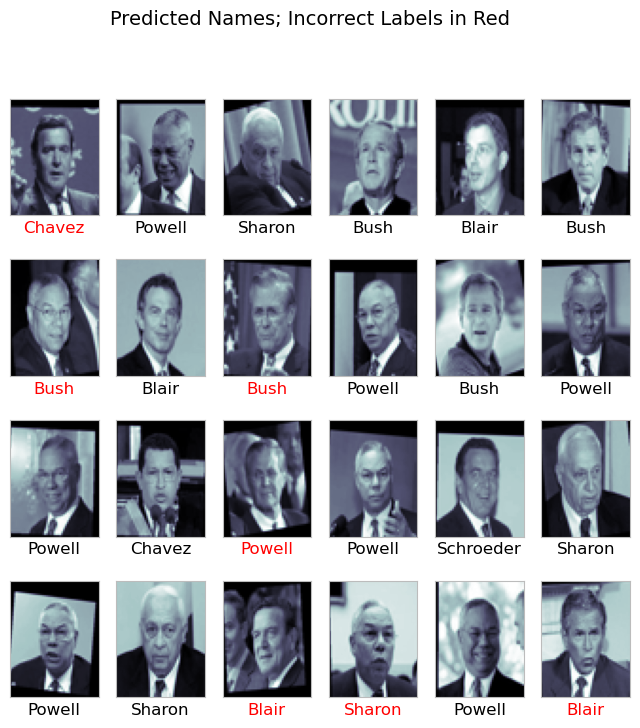

In [48]:
fig, ax = plt.subplots(4, 6, figsize=(8,8))
for i, axi in enumerate(ax.flat):
    axi.imshow(X_test[i].reshape(62, 47), cmap='bone')
    axi.set(xticks=[], yticks=[])
    axi.set_xlabel(faces.target_names[y_test[i]].split()[-1],
                   color='black' if y_test[i] == t_test[i] else 'red')
fig.suptitle('Predicted Names; Incorrect Labels in Red', size=14);

Out of this small sample, our optimal estimator mislabeled only a single face (Bush’s face in the bottom row was mislabeled as Blair). We can get a better sense of our estimator's performance using the classification report, which lists summary statistics label by label:

In [49]:
from sklearn.metrics import classification_report

print(classification_report(t_train, y_train, target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       1.00      1.00      1.00        61
     Colin Powell       0.99      1.00      0.99       189
  Donald Rumsfeld       1.00      1.00      1.00        97
    George W Bush       1.00      1.00      1.00       424
Gerhard Schroeder       1.00      1.00      1.00        87
      Hugo Chavez       1.00      1.00      1.00        57
Junichiro Koizumi       1.00      1.00      1.00        48
       Tony Blair       1.00      1.00      1.00       115

         accuracy                           1.00      1078
        macro avg       1.00      1.00      1.00      1078
     weighted avg       1.00      1.00      1.00      1078



In [50]:
print(classification_report(t_test, y_test, target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.79      0.69      0.73        16
     Colin Powell       0.77      0.77      0.77        47
  Donald Rumsfeld       0.57      0.54      0.55        24
    George W Bush       0.84      0.88      0.86       106
Gerhard Schroeder       0.78      0.64      0.70        22
      Hugo Chavez       0.68      0.93      0.79        14
Junichiro Koizumi       1.00      0.67      0.80        12
       Tony Blair       0.63      0.66      0.64        29

         accuracy                           0.77       270
        macro avg       0.76      0.72      0.73       270
     weighted avg       0.77      0.77      0.77       270



We might also display the confusion matrix between these classes:

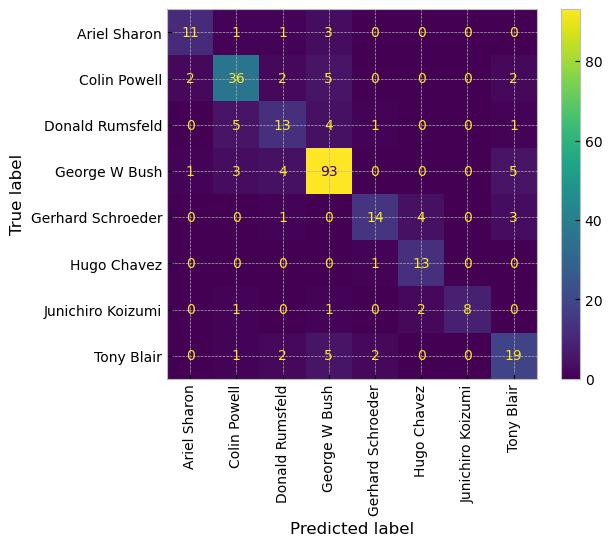

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

cm = confusion_matrix(t_test, y_test)

disp = ConfusionMatrixDisplay(cm, display_labels=faces.target_names)
disp.plot(xticks_rotation='vertical');

This helps us get a sense of which labels are likely to be confused by the classifier.

For a real-world facial recognition task, in which the photos do not come pre-cropped into nice grids, the only difference in the facial classification scheme is the feature selection: you would need to use a more sophisticated algorithm to find the faces, and extract features that are independent of the pixellation. 

* For this kind of application, one good option is to make use of [OpenCV](https://opencv.org/), which, among other things, includes pre-trained implementations of state-of-the-art feature extraction tools for images in general and faces in particular.

## Support Vector Machine Summary

We have seen here a brief intuitive introduction to the principals behind support vector machines. These methods are a powerful classification method for a number of reasons:

Their dependence on relatively few support vectors means that they are very compact models, and take up very little memory.
Once the model is trained, the prediction phase is very fast.
Because they are affected only by points near the margin, they work well with high-dimensional data—even data with more dimensions than samples, which is a challenging regime for other algorithms.
Their integration with kernel methods makes them very versatile, able to adapt to many types of data.
However, SVMs have several disadvantages as well:

The scaling with the number of samples $N$ is $\mathcal{O}[N^3]$ at worst, or $\mathcal{O}[N^2]$ for efficient implementations. For large numbers of training samples, this computational cost can be prohibitive.
The results are strongly dependent on a suitable choice for the softening parameter $C$. This must be carefully chosen via cross-validation, which can be expensive as datasets grow in size.
The results do not have a direct probabilistic interpretation. This can be estimated via an internal cross-validation (see the probability parameter of SVC), but this extra estimation is costly.
With those traits in mind, I generally only turn to SVMs once other simpler, faster, and less tuning-intensive methods have been shown to be insufficient for my needs. Nevertheless, if you have the CPU cycles to commit to training and cross-validating an SVM on your data, the method can lead to excellent results.

---
---
---

# SVM for Regression

<font color='red'>This section is informational only. SVM for regression will not be covered in the final exam.</font>

**Support vector regression** uses support vector machines to solve regression problems. For support vector regression, the hyperplane $y = \mathbf{w}^T\phi(\mathbf{x}) + b$ and the margin play a different role. Instead of being used as a decision boundary, the hyperplane is used to predict the value of a continuous output feature. The goal is to find the flattest $\epsilon$-tube around the hyperplane that contains the most training instances. The 
$\epsilon$-tube is a region around the hyperplane with a margin defined by $\epsilon$ where errors do not incur loss.

For the maximal margin case, all instances must fall inside the $\epsilon$-tube. In this case, finding the flattest 
$\epsilon$-tube is equivalent to solving the optimization problem

$$\arg_{\mathbf{w},b} \min \frac{1}{2} \Vert\mathbf{w}\Vert^2$$

with two constraints

\begin{align*}
t_n - y_n &\leq \epsilon\\
y_n - t_n &\leq \epsilon
\end{align*}

The magnitude of the weights, denoted by $\Vert\mathbf{w}\Vert$, can be interpreted as a measure of flatness. As the magnitude approaches 0, the coefficients of the weights become very small. Geometrically, smaller coefficients for the weights result in a flatter $\epsilon$-tube.

Like support vector classifiers, support vector regression is a distance-based algorithm. Thus, features need to be scaled before finding the hyperplane.

## Support Vector Regression with Soft-margin

In cases where no hyperplane can be found such that all instances lie within the $\epsilon$-tube, the optimization problem above can be modified to allow slack variables. A slack variable above the $\epsilon$-tube is denoted by $\xi_n$, while a slack variable below the $\epsilon$-tube is denoted by $\xi_n^*$.

For the soft margin case that allows slack variables, the optimization problem is

$$\arg_{\mathbf{w},b}\min \frac{1}{2}\Vert\mathbf{w}\Vert^2 + C \sum_{n=1}^N (\xi_n + \xi_n^*)$$

with constraints

\begin{align*}
t_n - y_n &\leq \epsilon + \xi\\
y_n - t_n &\leq \epsilon + \xi^*\\
\xi_n, \xi_n^* &\geq 0
\end{align*}

where $C$ is the hyperparameter representing the penalty for slack variables or errors.

A higher value for $C$ means a higher penalty is assigned toward errors, while a lower value means a lesser penalty.

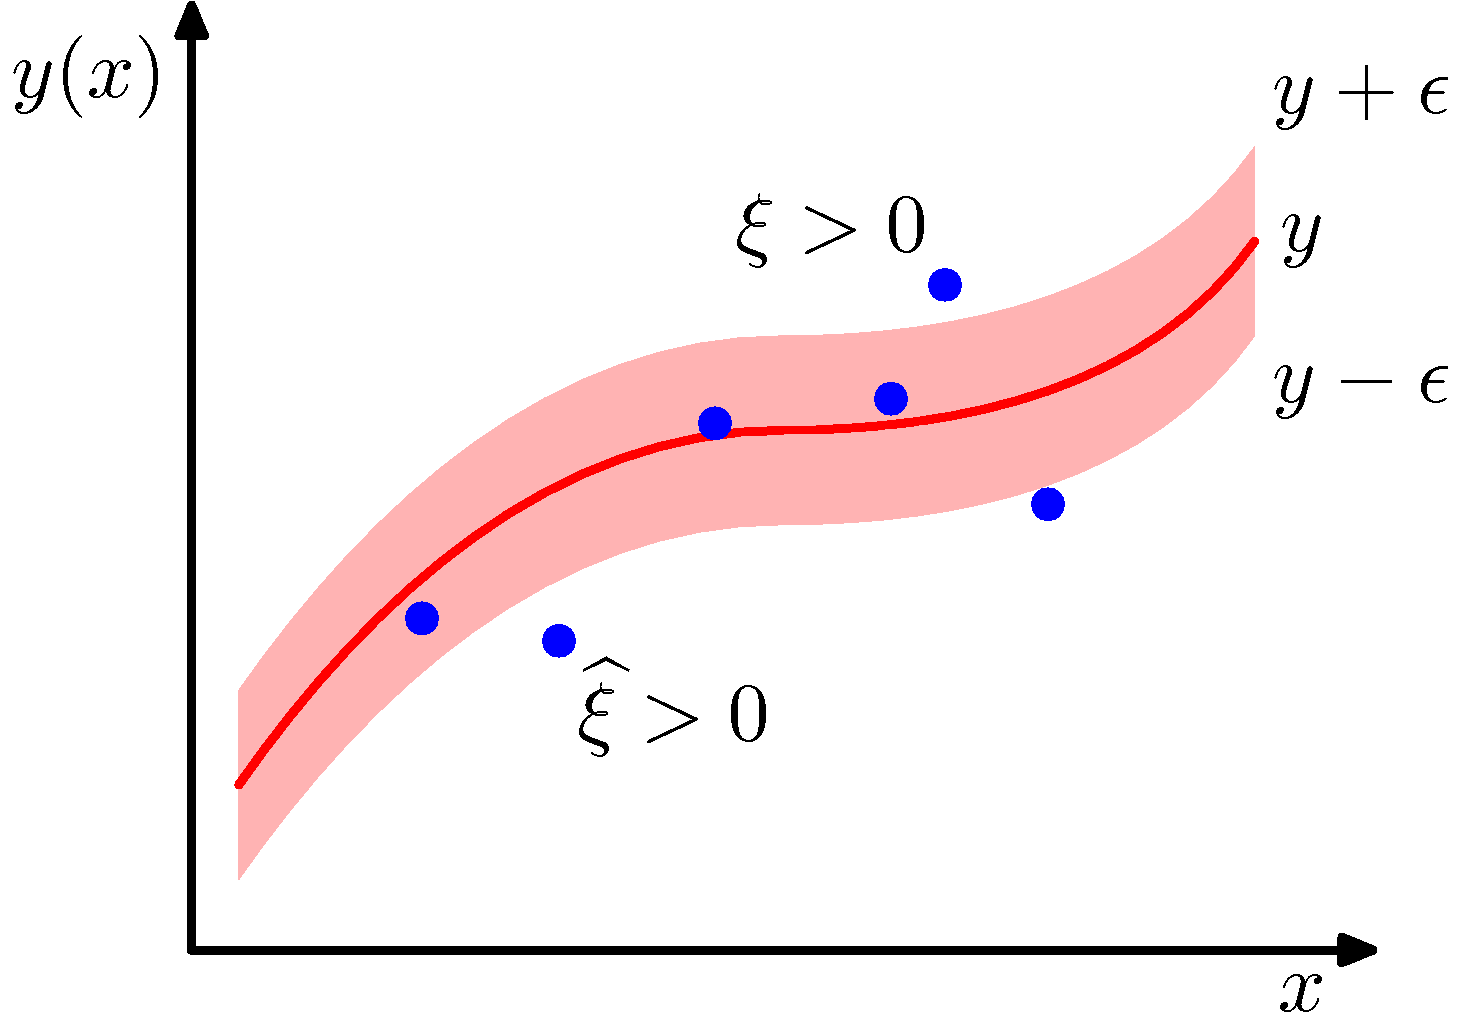

In [2]:
Image('figures/Figure7.7.png', width=400)
# Source: Bishop textbook

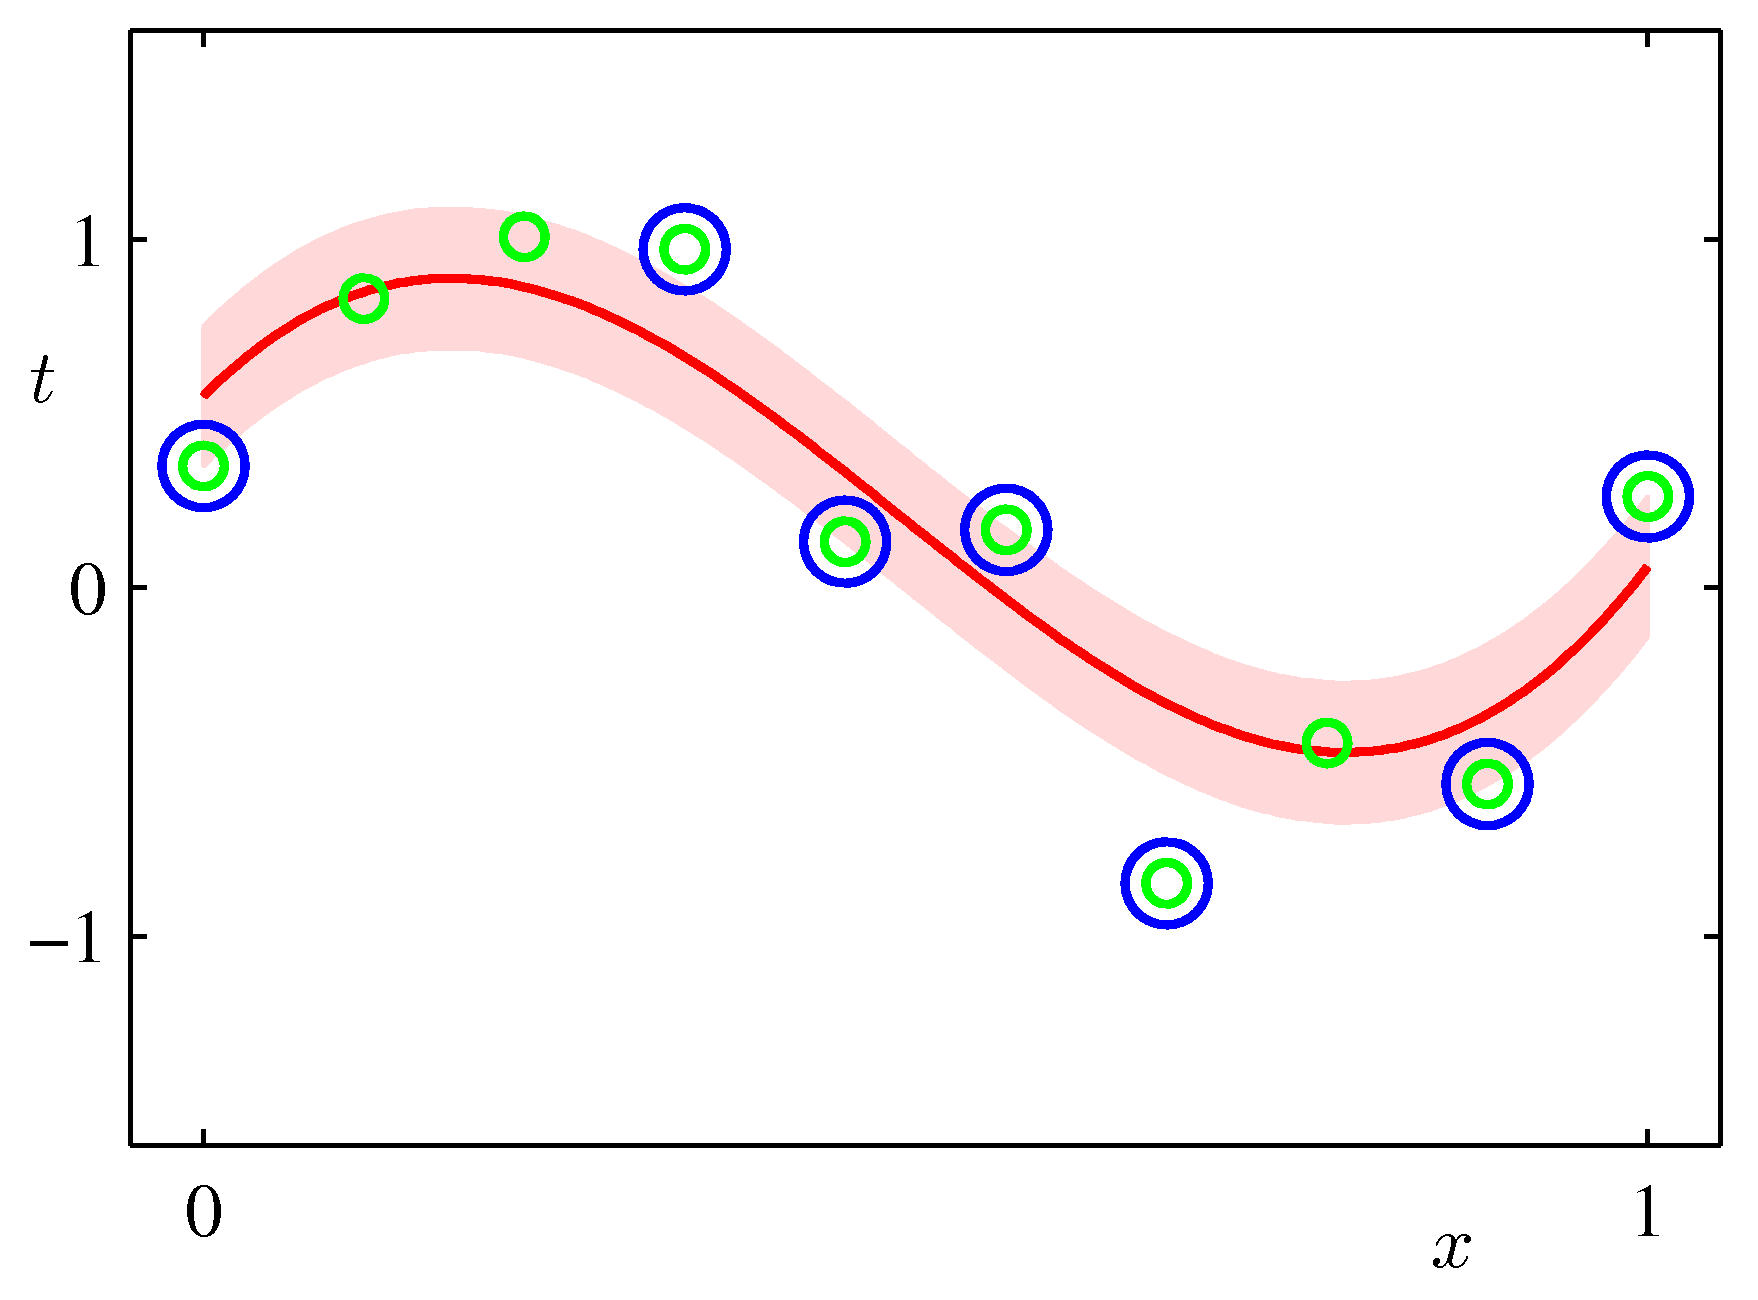

In [3]:
Image('figures/Figure7.8.png', width=400)
# Source: Bishop textbook

## Comparing Support Vector Regression with Linear Regression

Both support vector regression and linear regression use a hyperplane $y=\mathbf{w}^T\phi(\mathbf{x})+b$ to predict a continuous output feature. The difference between the two techniques is the expression being minimized. For support vector regression, the expression

$$\arg_{\mathbf{w},b}\min \frac{1}{2}\Vert\mathbf{w}\Vert^2 + C \sum_{n=1}^N (\xi_n + \xi_n^*)$$

is minimized. Only instances that lie outside of the $\epsilon$-tube incur loss.

The **$\epsilon$-loss insensitive function**, denoted by $\mathcal{L}_{\epsilon}(t,y)$, is a loss function commonly used with support vector regression. $\mathcal{L}_{\epsilon}(t,y)$ has a value of 0 if the instance is within the margins. Otherwise, the loss function has a value of $|t_n-y_n|-\epsilon$, which is the deviation of the slack variable from the margin.

For linear regression using least squares, the expression

$$\sum_{n=1}^N \frac{1}{2}(t_n - y_n)^2 = \frac{1}{2}\sum_{n=1}^N\left(t_n - (\mathbf{w}^T\phi(\mathbf{x}_n) + b) \right)^2$$

is minimized. All instances that are not on the hyperplane incur loss.

| Support Vector Regression | Linear Regression | 
| -- | -- |
| Minimizes weights of the hyperplane. | Minimizes least squares error. |
| *Only* samples outside the $\epsilon$-tube incur loss. | All samples not on the hyperplane incur loss.|
| Soft-margin case is more robust to outliers. | More susceptible to outliers.|

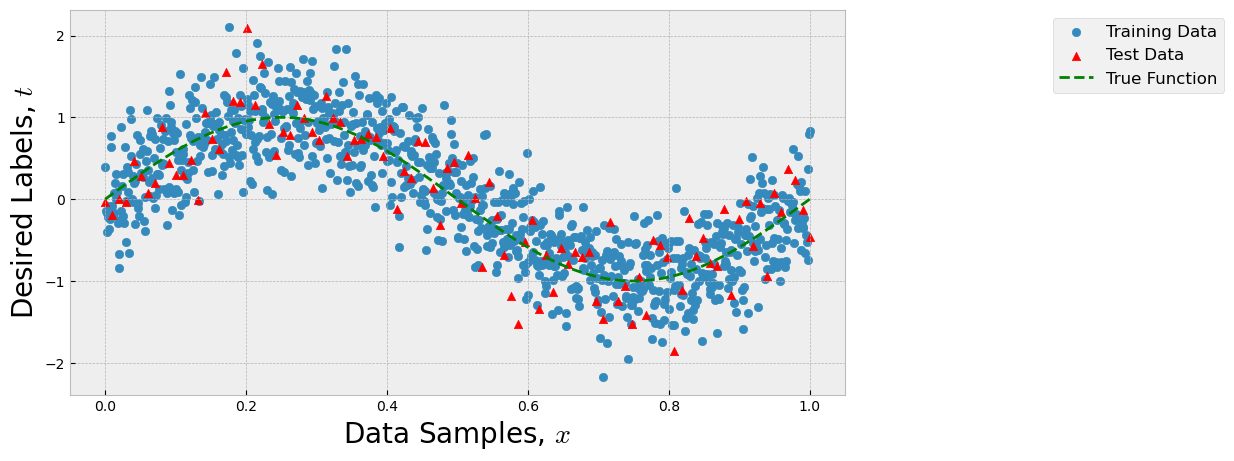

In [52]:
def NoisySinusoidalData(N, a, b, sigma):
    '''Generates N data points in the range [a,b) sampled from a sin(2*pi*x) 
    with additive zero-mean Gaussian random noise with standard deviation sigma'''
    # N input samples, evenly spaced numbers between [a,b) incrementing by 1/N
    x = np.linspace(a,b,N)
    # draw N sampled from a univariate Gaussian distribution with mean 0, sigma standard deviation and N data points
    noise = np.random.normal(0,sigma,N)
    # desired values, noisy sinusoidal
    t = np.sin(2*np.pi*x) + noise
    return x.reshape(-1, 1), t

# Generate input samples and desired values
N_train = 1000 # number of data samples for training
N_test = 100 # number of data samples for test
a, b = [0,1] # data samples interval
sigma = 0.4 # standard deviation of the zero-mean Gaussian noise
x_train, t_train = NoisySinusoidalData(N_train, a, b, sigma) # Training Data - Noisy sinusoidal
x_true, t_true = NoisySinusoidalData(N_train, a, b, 0) # True Sinusoidal - in practice, we don't have the true function
x_test, t_test = NoisySinusoidalData(N_test, a, b, sigma) # Test Data - Noisy sinusoidal

fig=plt.figure(figsize=(10,5))
plt.scatter(x_train,t_train, label='Training Data')
plt.scatter(x_test,t_test, c='r', marker='^', label='Test Data')
plt.plot(x_true, t_true,'--g', label = 'True Function')
plt.legend(bbox_to_anchor=(1.5, 1),fontsize=12,ncol=1)
plt.xlabel('Data Samples, $x$', fontsize=20)
plt.ylabel('Desired Labels, $t$', fontsize=20);

In [53]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.svm import SVR
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
# SVR?

In [54]:
lr = Pipeline([('scaler', StandardScaler()),
               ('poly_feat', PolynomialFeatures(degree=4)),
              ('LR', LinearRegression())])

lr.fit(x_train, t_train.reshape(-1, 1))

Pipeline(steps=[('scaler', StandardScaler()),
                ('poly_feat', PolynomialFeatures(degree=4)),
                ('LR', LinearRegression())])

In [56]:
gamma=1
svr = Pipeline([('scaler', StandardScaler()),
              ('SVR', SVR(kernel='rbf', gamma=gamma, C=10, epsilon=0.9))])

svr.fit(x_train, t_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('SVR', SVR(C=10, epsilon=0.9, gamma=1))])

In [57]:
sv_ind = svr.named_steps['SVR'].support_
sv_ind

array([ 20,  35, 106, 175, 229, 237, 327, 342, 416, 455, 480, 598, 706,
       741, 809, 847, 904, 917, 926], dtype=int32)

In [58]:
xplot = np.linspace(0,1,1000).reshape(-1,1)

y_lr  = lr.predict(xplot)
y_svr = svr.predict(xplot)

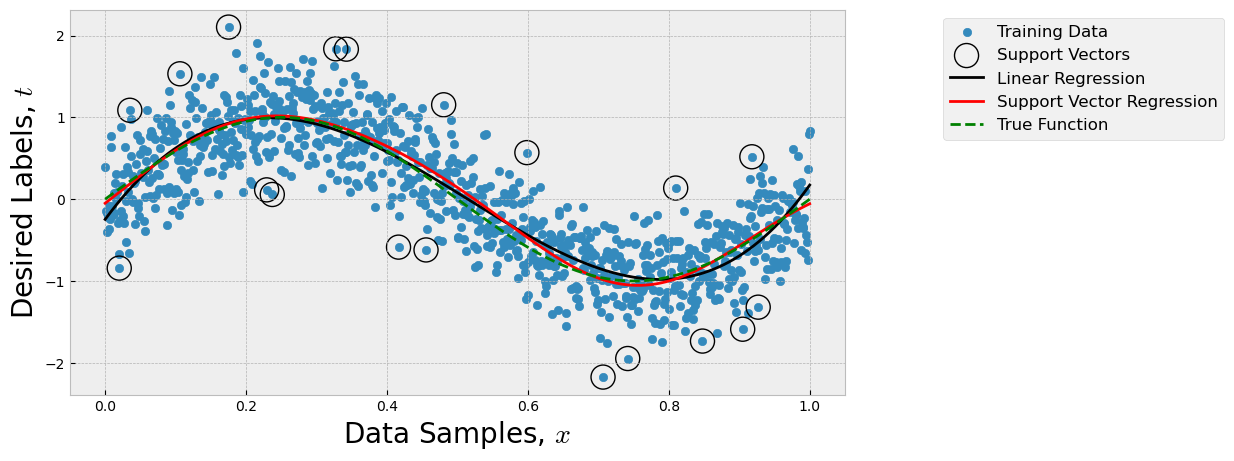

In [59]:
fig=plt.figure(figsize=(10,5))
plt.scatter(x_train,t_train, label='Training Data')
plt.scatter(x_train[sv_ind], t_train[sv_ind], s=300, linewidth=1, 
            edgecolors='black',facecolors='none', label='Support Vectors');
plt.plot(xplot, y_lr, 'k', label='Linear Regression')
plt.plot(xplot, y_svr, 'r', label='Support Vector Regression')
plt.plot(x_true, t_true,'--g', label = 'True Function')
plt.legend(bbox_to_anchor=(1.5, 1),fontsize=12,ncol=1)
plt.xlabel('Data Samples, $x$', fontsize=20)
plt.ylabel('Desired Labels, $t$', fontsize=20);

In [60]:
len(svr.named_steps['SVR'].support_vectors_)

19

In [61]:
# Dual coefficients (Lagrange multipliers)

a = svr.named_steps['SVR'].dual_coef_.T
a

# we will have as many coefficients as there are support vectors.
# Coefficients for non-support-vectors are 0.

array([[-10.        ],
       [  7.16301371],
       [  2.74451536],
       [ 10.        ],
       [ -9.26300438],
       [-10.        ],
       [ 10.        ],
       [ 10.        ],
       [-10.        ],
       [-10.        ],
       [  6.35741694],
       [ 10.        ],
       [-10.        ],
       [ -3.16996823],
       [ 10.        ],
       [ -3.12434832],
       [-10.        ],
       [ 10.        ],
       [ -0.70762508]])

In [62]:
b = svr.named_steps['SVR'].intercept_
b

array([-0.09793063])

In [63]:
support_vectors = svr.named_steps['SVR'].support_vectors_
support_vectors

array([[-1.66103755],
       [-1.609076  ],
       [-1.36312467],
       [-1.12410154],
       [-0.93703996],
       [-0.90932713],
       [-0.59755783],
       [-0.54559628],
       [-0.28925263],
       [-0.1541526 ],
       [-0.06755002],
       [ 0.34121418],
       [ 0.71533734],
       [ 0.83658096],
       [ 1.07213999],
       [ 1.20377591],
       [ 1.4012298 ],
       [ 1.44626315],
       [ 1.47744008]])

---